In [23]:
import warnings
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from scipy.stats import chi2_contingency, mannwhitneyu

from sklearn.metrics import precision_score, recall_score
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    f1_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.calibration import calibration_curve

from catboost import CatBoostClassifier, Pool
import lightgbm as lgb

warnings.filterwarnings("ignore")

# ── Constants ─────────────────────────────────────────────────────────────────
DATA_PATH    = "train_df.csv"
TARGET_COL   = "gb"
ID_COL       = "id"
RANDOM_STATE = 42
N_SPLITS     = 5

# Color palette for plots
PALETTE = {
    "primary":   "#2E86AB",
    "secondary": "#A23B72",
    "accent":    "#F18F01",
    "pos":       "#C73E1D",
    "neg":       "#3A7D44",
}

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette([PALETTE["primary"], PALETTE["secondary"], PALETTE["accent"]])
plt.rcParams.update({"figure.dpi": 100, "axes.titlesize": 13, "axes.labelsize": 11})
%matplotlib inline

np.random.seed(RANDOM_STATE)
print("All imports loaded successfully.")

All imports loaded successfully.


In [2]:
df = pd.read_csv('train_df.csv', sep='\t')

Creating a list of "usuble" columns for train, we can explore it, and with this columns  our model actually learns.

In [3]:
num_cols = sorted(c for c in df.columns if c.startswith("num_"))
cat_cols = sorted(c for c in df.columns if c.startswith("cat_"))
feature_cols = num_cols + cat_cols

In [4]:
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print(f"Number of uniqe ID's: {df['id'].nunique()}")

Rows: 26824, Columns: 554
Number of uniqe ID's: 5243


As we see here, users make many things in our dataset, so, to prevent data leakeage in future, we change we method, how we sliit aour dataset for train/test parts

In [5]:
target_counts = df['gb'].value_counts().sort_index()
pos_rate = df['gb'].mean()
imbalance_ratio = target_counts[0] / target_counts[1]

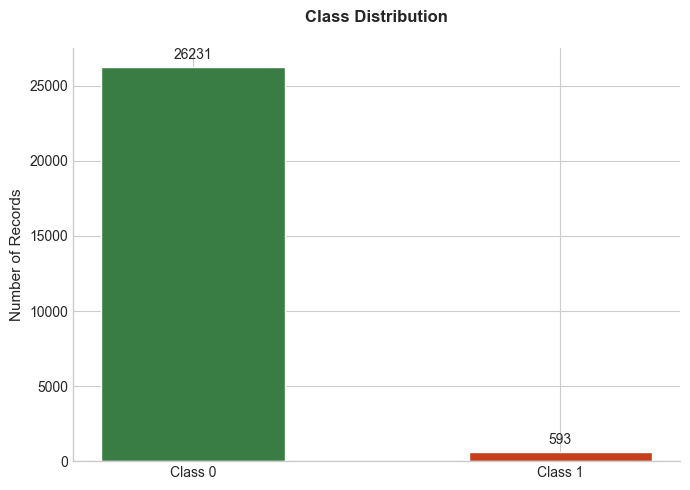

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(
    ["Class 0", "Class 1"],
    target_counts.values,
    color=[PALETTE["neg"], PALETTE["pos"]],
    edgecolor="white", 
    width=0.5
)

ax.bar_label(bars, padding=4, fmt="%d")

ax.set_title(
    f"Class Distribution\n",
    fontsize=12,
    fontweight="bold"
)
ax.set_ylabel("Number of Records", fontsize=11)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

We need to find out, what key matrices we will using to understand, if our model perform well. We have class imbalance, chus pression, recall, Roc-auc and f1 will be in this list

In [7]:
missing_pct = df[feature_cols].isnull().mean() * 100
empty_cols = missing_pct[missing_pct >= 100].index.tolist()

print(f"Number of emtry columns: {len(empty_cols)}")

Number of emtry columns: 12


This columns not given us any usefull information, but takes power from our systen, chus the best desicion in to delete it.

Median skewness: 10.00
Features with |skewness| > 5: 258
Features with |skewness| > 10: 202


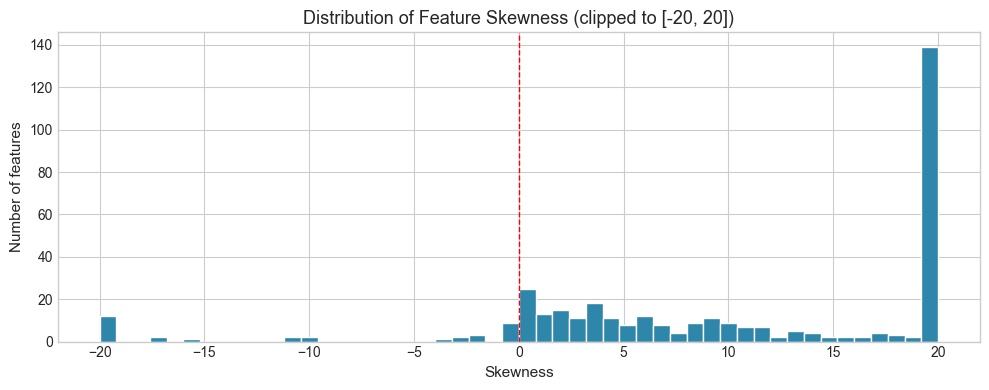

In [9]:
# Skewness and outlier analysis
valid_num_cols = [c for c in num_cols if df[c].notna().any() and df[c].notna().sum() > 100]

skew_series = df[valid_num_cols].skew().sort_values(ascending=False)
print(f"Median skewness: {skew_series.median():.2f}")
print(f"Features with |skewness| > 5: {(skew_series.abs() > 5).sum()}")
print(f"Features with |skewness| > 10: {(skew_series.abs() > 10).sum()}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(skew_series.clip(-20, 20), bins=50, color=PALETTE["primary"], edgecolor="white")
ax.set_xlabel("Skewness")
ax.set_ylabel("Number of features")
ax.set_title("Distribution of Feature Skewness (clipped to [-20, 20])")
ax.axvline(0, color="red", ls="--", lw=1)
plt.tight_layout()
plt.show()

This graph is a histogram of feature skewness.
Skewness measures how asymmetrical your data distribution is. A perfectly symmetrical bell curve has a skewness of 0. Our dataset is packed with features that have massive, long tails or extreme outliers. 
SO, when weare using Tree-Based Models, we dont need to scale skewness, becouse the way they works. They make decision by splitting data based on threshplds, and after that minimizing entropy. But, for the logistic regression we use miplitlies weghts by feature values, so, after seeing so much out liear we need to use skeiler. Anf we choose Robust scaler.  it users median and IQR, so, huge number and median does break in those cases.

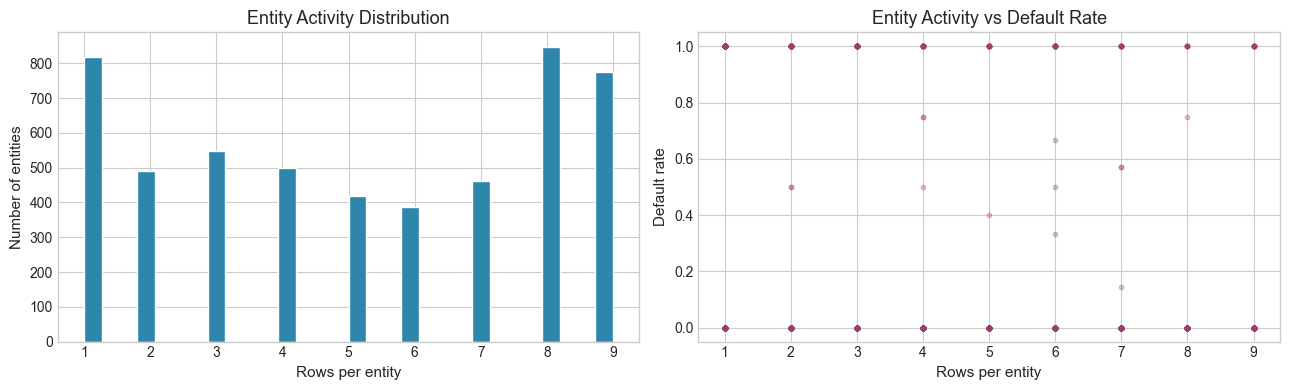

Entity row count stats: mean=5.1, median=5, max=9


In [10]:
# Entity activity: rows per ID vs default rate
entity_stats = df.groupby(ID_COL).agg(
    n_rows=(TARGET_COL, "count"),
    default_rate=(TARGET_COL, "mean"),
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(entity_stats["n_rows"], bins=30, color=PALETTE["primary"], edgecolor="white")
axes[0].set_xlabel("Rows per entity")
axes[0].set_ylabel("Number of entities")
axes[0].set_title("Entity Activity Distribution")

axes[1].scatter(entity_stats["n_rows"], entity_stats["default_rate"],
                alpha=0.3, s=10, color=PALETTE["secondary"])
axes[1].set_xlabel("Rows per entity")
axes[1].set_ylabel("Default rate")
axes[1].set_title("Entity Activity vs Default Rate")

plt.tight_layout()
plt.show()

print(f"Entity row count stats: mean={entity_stats['n_rows'].mean():.1f}, "
      f"median={entity_stats['n_rows'].median():.0f}, "
      f"max={entity_stats['n_rows'].max()}")

In [25]:
# Mann-Whitney U test: which numerical features differ significantly between classes?
mw_results = []
valid_num_cols = [c for c in num_cols if df[c].notna().any() and df[c].notna().sum() > 100]

for col in valid_num_cols:
    vals_0 = df.loc[df[TARGET_COL] == 0, col].dropna()
    vals_1 = df.loc[df[TARGET_COL] == 1, col].dropna()
    if len(vals_0) < 10 or len(vals_1) < 10:
        continue
    stat, pval = mannwhitneyu(vals_0, vals_1, alternative="two-sided")
    mw_results.append({"column": col, "p_value": pval, "median_gb0": vals_0.median(), "median_gb1": vals_1.median()})

mw_df = pd.DataFrame(mw_results).sort_values("p_value")
significant = mw_df[mw_df["p_value"] < 0.05]
print(f"Numerical features significantly different between classes (p<0.05): {len(significant)} / {len(mw_df)}")
display(significant.head(15))

Numerical features significantly different between classes (p<0.05): 217 / 286


,column,p_value,median_gb0,median_gb1
5,num_105,4.972279e-82,-12423.760,-95489.150
77,num_197,4.514105e-79,13.000,6.000
246,num_43,1.134797e-74,330000.000,1295417.480
24,num_132,2.375108e-66,57.000,33.000
185,num_340,4.257951e-66,1721.000,1000.000
26,num_134,4.257951e-66,1717.000,996.000
135,num_276,2.634840e-63,27959.885,126871.460
52,num_169,1.210315e-59,17221.735,77870.775
109,num_234,1.198603e-58,1385.000,633.000
110,num_235,1.672505e-58,46.000,21.000


**Why:** The Mann-Whitney U test is a non-parametric test that checks if the distribution of each numerical feature differs between the two target classes. Features with very low p-values are statistically associated with default — they are the most promising predictors. We use Mann-Whitney (not t-test) because financial data is typically heavily skewed and non-normal.

In [26]:
# Chi-squared test for categorical features vs target
chi2_results = []
for col in cat_cols:
    ct = pd.crosstab(df[col], df[TARGET_COL])
    if ct.shape[0] < 2 or ct.shape[1] < 2:
        continue
    chi2, pval, dof, _ = chi2_contingency(ct)
    chi2_results.append({"column": col, "chi2": chi2, "p_value": pval, "dof": dof, "cardinality": df[col].nunique()})

chi2_df = pd.DataFrame(chi2_results).sort_values("p_value")
chi2_sig = chi2_df[chi2_df["p_value"] < 0.05]
print(f"Categorical features significantly associated with target (p<0.05): {len(chi2_sig)} / {len(chi2_df)}")
display(chi2_df.head(15))

Categorical features significantly associated with target (p<0.05): 69 / 126


,column,chi2,p_value,dof,cardinality
87,cat_60,6433.486756,0.000000e+00,1312,1313
124,cat_98,3907.659332,3.659045e-222,1460,1461
64,cat_38,1825.682268,8.277044e-172,427,428
94,cat_68,621.776614,9.614437e-136,2,3
11,cat_109,617.136939,3.028121e-132,4,5
44,cat_19,1895.846118,4.448282e-127,629,630
7,cat_105,313.390590,8.873561e-69,2,3
20,cat_117,173.847478,1.776233e-38,2,3
69,cat_43,161.162237,1.009404e-35,2,3
53,cat_27,151.733015,3.327455e-30,6,7


Max cardinality: 1461 (column: cat_98)
Features with cardinality > 20: 8
Features with cardinality <= 5: 110


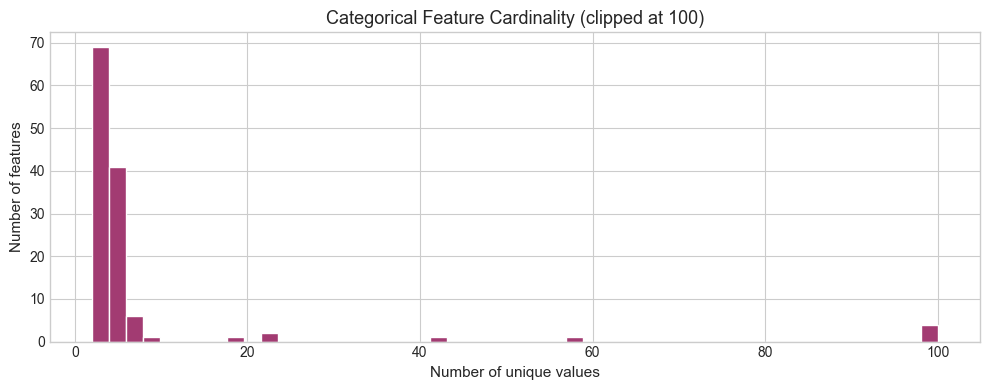

In [27]:
# Categorical feature cardinality
cardinality = df[cat_cols].nunique().sort_values(ascending=False)
print(f"Max cardinality: {cardinality.max()} (column: {cardinality.idxmax()})")
print(f"Features with cardinality > 20: {(cardinality > 20).sum()}")
print(f"Features with cardinality <= 5: {(cardinality <= 5).sum()}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(cardinality.clip(0, 100), bins=50, color=PALETTE["secondary"], edgecolor="white")
ax.set_xlabel("Number of unique values")
ax.set_ylabel("Number of features")
ax.set_title("Categorical Feature Cardinality (clipped at 100)")
plt.tight_layout()
plt.show()

We need to understand how spleing, so, based on this we will use `StratifiedGroupKFold` (splitting by `id` groups) instead of simple `train_test_split`.

So, beafore working with dataset, and do it, we need to clean it.

In [11]:
cols_before = len(df.columns)
df = df.drop(columns=empty_cols, errors="ignore")
print(f"Dropped {cols_before - len(df.columns)} columns with 100% missing values.")

# Update column lists
cat_cols = sorted([c for c in df.columns if c.startswith("cat_")])
num_cols = sorted([c for c in df.columns if c.startswith("num_")])

# ── Step 2: Drop exact duplicate columns ─────────────────────────────────────
feature_cols = cat_cols + num_cols
dup_groups = df[feature_cols].T.duplicated(keep="first")
dup_cols = dup_groups[dup_groups].index.tolist()
df = df.drop(columns=dup_cols, errors="ignore")
print(f"Dropped {len(dup_cols)} exact duplicate columns.")

cat_cols = sorted([c for c in df.columns if c.startswith("cat_")])
num_cols = sorted([c for c in df.columns if c.startswith("num_")])

FINAL_FEATURES = cat_cols + num_cols

print(f"\n=== Final feature set: {len(cat_cols)} categorical + {len(num_cols)} numerical = {len(FINAL_FEATURES)} total ===")

Dropped 12 columns with 100% missing values.
Dropped 33 exact duplicate columns.

=== Final feature set: 126 categorical + 380 numerical = 506 total ===


In [16]:
# ── Common preprocessing applied to the whole dataset ────────────────────────
# This only includes operations that don't leak information from val into train:
#   - Casting categorical columns to int
#   - Extracting X, y, and groups

# Make sure categoricals are int-typed (they are integer codes already)
for col in cat_cols:
    df[col] = df[col].fillna(-1).astype(int)

X_all = df[FINAL_FEATURES].copy()
y_all = df[TARGET_COL].values
groups_all = df[ID_COL].values

# Identify which final features are MNAR (for LR missing indicators)
final_num = [c for c in FINAL_FEATURES if c.startswith("num_")]
final_cat = [c for c in FINAL_FEATURES if c.startswith("cat_")]

final_num = [c for c in FINAL_FEATURES if c.startswith("num_")]
final_cat = [c for c in FINAL_FEATURES if c.startswith("cat_")]

# ✅ Додай це:
# MNAR = числові колонки з пропусками (для них додамо бінарний індикатор is_missing)
final_mnar = [c for c in final_num if X_all[c].isnull().any()]

print(f"MNAR columns (with missings): {len(final_mnar)}")

print(f"X_all shape: {X_all.shape}")
print(f"Final numerical:   {len(final_num)}")
print(f"Final categorical: {len(final_cat)}")
print(f"Target balance: {pd.Series(y_all).value_counts(normalize=True).round(4).to_dict()}")

MNAR columns (with missings): 319
X_all shape: (26824, 506)
Final numerical:   380
Final categorical: 126
Target balance: {0: 0.9779, 1: 0.0221}


In [17]:
# StratifiedGroupKFold: stratifies by target, groups by entity ID
# This ensures:
#  1. No entity appears in both train and val (prevents leakage)
#  2. Each fold has roughly the same positive class rate

entity_target = df.groupby(ID_COL)[TARGET_COL].first().reset_index()
entity_y = df[ID_COL].map(entity_target.set_index(ID_COL)[TARGET_COL]).values

sgkf = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
splits = list(sgkf.split(X_all, entity_y, groups=groups_all))

print(f"CV splits (StratifiedGroupKFold, {N_SPLITS} folds):")
for i, (tr, va) in enumerate(splits):
    n_groups_tr = len(set(groups_all[tr]))
    n_groups_va = len(set(groups_all[va]))
    overlap = set(groups_all[tr]) & set(groups_all[va])
    print(f"  Fold {i}: train={len(tr):,} rows ({n_groups_tr} entities), "
          f"val={len(va):,} rows ({n_groups_va} entities), "
          f"val positive rate={y_all[va].mean():.2%}, "
          f"id overlap={len(overlap)}")

CV splits (StratifiedGroupKFold, 5 folds):
  Fold 0: train=21,510 rows (4195 entities), val=5,314 rows (1048 entities), val positive rate=2.80%, id overlap=0
  Fold 1: train=21,402 rows (4194 entities), val=5,422 rows (1049 entities), val positive rate=1.83%, id overlap=0
  Fold 2: train=21,487 rows (4194 entities), val=5,337 rows (1049 entities), val positive rate=2.59%, id overlap=0
  Fold 3: train=21,429 rows (4195 entities), val=5,395 rows (1048 entities), val positive rate=1.98%, id overlap=0
  Fold 4: train=21,468 rows (4194 entities), val=5,356 rows (1049 entities), val positive rate=1.87%, id overlap=0


In [20]:
# ── Helper: sanitize column names (LightGBM/CatBoost don't like special chars) ──
def sanitize_names(cols):
    """Replace special characters in column names."""
    return [re.sub(r"[^\w]", "_", c) for c in cols]


# ── Helper: label encode categoricals (leakage-safe: fit on train only) ──
def encode_categoricals(X_train, X_val, cat_cols):
    """Label encoding fitted on train, applied to val."""
    X_tr, X_va = X_train.copy(), X_val.copy()
    for col in cat_cols:
        if col not in X_tr.columns:
            continue
        uniques = X_tr[col].astype(str).fillna("__NA__").unique()
        mapping = {v: i for i, v in enumerate(sorted(uniques))}
        X_tr[col] = X_tr[col].astype(str).fillna("__NA__").map(mapping).fillna(-1).astype(int)
        X_va[col] = X_va[col].astype(str).fillna("__NA__").map(mapping).fillna(-1).astype(int)
    return X_tr, X_va


# ── Preprocessing for LOGISTIC REGRESSION ────────────────────────────────────
def prepare_for_logreg(X_train, X_val, mnar_cols, num_cols, cat_cols):
    """
    Full preprocessing pipeline for Logistic Regression:
      1. Add binary is_missing indicators for MNAR columns
      2. Label encode categoricals (fit on train)
      3. Median imputation (fit on train)
      4. RobustScaler (fit on train)
    """
    X_tr = X_train.copy()
    X_va = X_val.copy()
    
    # 1. MNAR indicators
    for col in mnar_cols:
        if col in X_tr.columns:
            X_tr[f"{col}__miss"] = X_tr[col].isnull().astype(np.int8)
            X_va[f"{col}__miss"] = X_va[col].isnull().astype(np.int8)

    # 2. Label encoding
    X_tr, X_va = encode_categoricals(X_tr, X_va, cat_cols)

    # 3. Median imputation (fitted on train)
    # ✅ Виправлена версія:
    medians = X_tr.median()
    medians = medians.fillna(0)   # fallback: якщо вся колонка NaN → заповнюємо 0
    X_tr = X_tr.fillna(medians)
    X_va = X_va.fillna(medians)

    # 4. RobustScaler (fitted on train)
    all_cols = X_tr.columns.tolist()
    scaler = RobustScaler()
    X_tr_s = pd.DataFrame(scaler.fit_transform(X_tr), columns=all_cols, index=X_tr.index)
    X_va_s = pd.DataFrame(scaler.transform(X_va), columns=all_cols, index=X_va.index)

    return X_tr_s, X_va_s


# ── Preprocessing for TREE MODELS (CatBoost, LightGBM) ──────────────────────
def prepare_for_trees(X_train, X_val, cat_cols):
    """
    Minimal preprocessing for tree-based models:
      - Label encode categoricals (fit on train)
      - NaN values are kept as-is (CatBoost/LightGBM handle them natively)
      - No scaling needed (trees are scale-invariant)
    """
    return encode_categoricals(X_train, X_val, cat_cols)


# ── Helper: find optimal F1 threshold ────────────────────────────────────────
def find_optimal_f1(y_true, y_prob, n=200):
    """Search for the probability threshold that maximizes F1-score."""
    thresholds = np.linspace(0.001, 0.999, n)
    best_f1, best_t = 0.0, 0.5
    for t in thresholds:
        f1 = f1_score(y_true, (y_prob >= t).astype(int), zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return best_t, best_f1


print("Preprocessing functions defined.")

Preprocessing functions defined.


In [29]:
# ── Відбираємо тільки статистично значущі фічі для Logistic Regression ────────

# Числові: значущі за Mann-Whitney (p < 0.05)
sig_num = significant["column"].tolist()

# Категоріальні: значущі за Chi-squared (p < 0.05)
sig_cat = chi2_sig["column"].tolist()

# MNAR: тільки серед відібраних числових
sig_mnar = [c for c in sig_num if X_all[c].isnull().any()]

print(f"Features for LR:")
print(f"  Numerical  (sig): {len(sig_num)}  (було {len(final_num)})")
print(f"  Categorical(sig): {len(sig_cat)}  (було {len(final_cat)})")
print(f"  MNAR indicators : {len(sig_mnar)}")

# Новий X_all тільки зі значущими фічами
sig_features = sig_num + sig_cat
X_all_lr = X_all[sig_features].copy()

Features for LR:
  Numerical  (sig): 217  (було 380)
  Categorical(sig): 69  (було 126)
  MNAR indicators : 166


  Fold 0: PR-AUC=0.0361 | ROC-AUC=0.6060 | F1=0.0548 | Precision=0.0282 | Recall=1.0000 (thr=0.497)
  Fold 1: PR-AUC=0.0300 | ROC-AUC=0.5582 | F1=0.1111 | Precision=0.2593 | Recall=0.0707 (thr=0.538)
  Fold 2: PR-AUC=0.0273 | ROC-AUC=0.5226 | F1=0.0505 | Precision=0.0259 | Recall=1.0000 (thr=0.482)
  Fold 3: PR-AUC=0.0233 | ROC-AUC=0.6095 | F1=0.0401 | Precision=0.0204 | Recall=1.0000 (thr=0.497)
  Fold 4: PR-AUC=0.0477 | ROC-AUC=0.6389 | F1=0.0405 | Precision=0.0625 | Recall=0.0300 (thr=0.503)

Logistic Regression — mean CV:
  pr_auc      : 0.0329 ± 0.0095
  roc_auc     : 0.5870 ± 0.0462
  f1          : 0.0594 ± 0.0296
  precision   : 0.0793 ± 0.1020
  recall      : 0.6201 ± 0.5203


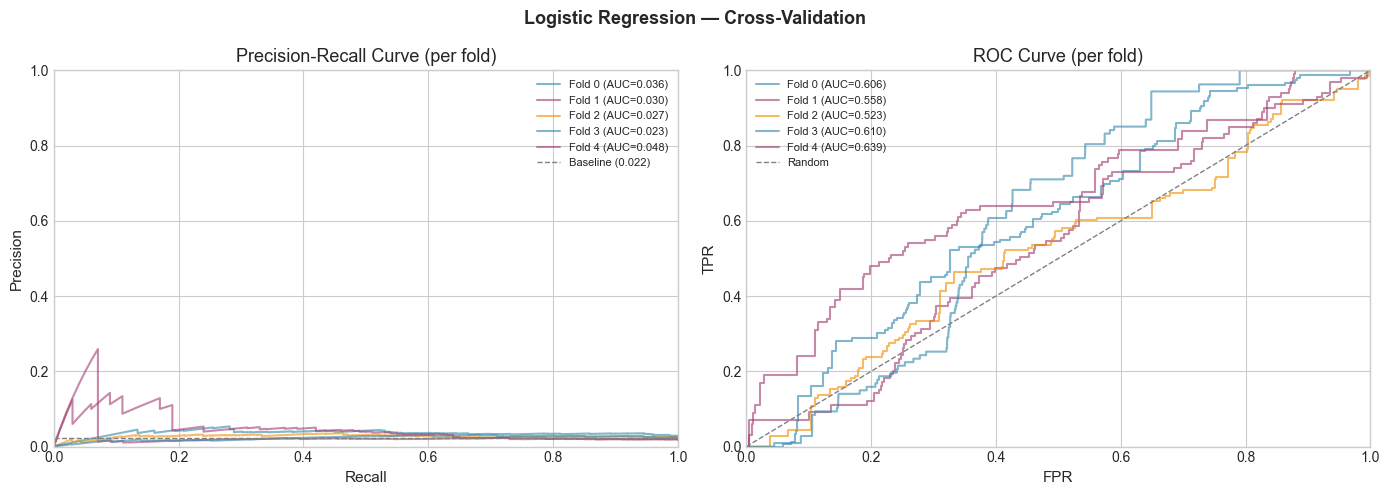

In [30]:
oof_lr = np.full(len(y_all), np.nan)
lr_fold_metrics = []

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for fold_idx, (train_idx, val_idx) in enumerate(splits):
    X_tr_raw = X_all_lr.iloc[train_idx]   # ← змінено
    X_va_raw = X_all_lr.iloc[val_idx] 
    y_tr = y_all[train_idx]
    y_va = y_all[val_idx]

    X_tr_lr, X_va_lr = prepare_for_logreg(
        X_tr_raw, X_va_raw, final_mnar, final_num, final_cat
    )

    lr = LogisticRegression(
        C=0.1, penalty="l2", solver="saga", max_iter=300,
        class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1,
    )
    lr.fit(X_tr_lr, y_tr)
    val_prob = lr.predict_proba(X_va_lr)[:, 1]
    oof_lr[val_idx] = val_prob

    # ── Metrics ───────────────────────────────────────────────────────────────
    pr_auc  = average_precision_score(y_va, val_prob)
    roc_auc = roc_auc_score(y_va, val_prob)

    best_t, best_f1 = find_optimal_f1(y_va, val_prob)
    y_pred = (val_prob >= best_t).astype(int)
    precision = precision_score(y_va, y_pred, zero_division=0)
    recall    = recall_score(y_va, y_pred, zero_division=0)

    lr_fold_metrics.append({
        "fold": fold_idx, "pr_auc": pr_auc, "roc_auc": roc_auc,
        "precision": precision, "recall": recall, "f1": best_f1, "threshold": best_t,
    })
    print(
        f"  Fold {fold_idx}: PR-AUC={pr_auc:.4f} | ROC-AUC={roc_auc:.4f} | "
        f"F1={best_f1:.4f} | Precision={precision:.4f} | Recall={recall:.4f} "
        f"(thr={best_t:.3f})"
    )

    # ── PR curve per fold ─────────────────────────────────────────────────────
    prec_c, rec_c, _ = precision_recall_curve(y_va, val_prob)
    fpr, tpr, _      = roc_curve(y_va, val_prob)

    axes[0].plot(rec_c, prec_c, alpha=0.6, label=f"Fold {fold_idx} (AUC={pr_auc:.3f})")
    axes[1].plot(fpr,   tpr,    alpha=0.6, label=f"Fold {fold_idx} (AUC={roc_auc:.3f})")

# ── Summary ───────────────────────────────────────────────────────────────────
lr_metrics_df = pd.DataFrame(lr_fold_metrics)

print(f"\nLogistic Regression — mean CV:")
for col in ["pr_auc", "roc_auc", "f1", "precision", "recall"]:
    print(f"  {col:12s}: {lr_metrics_df[col].mean():.4f} ± {lr_metrics_df[col].std():.4f}")

# ── Finish plots ──────────────────────────────────────────────────────────────
baseline = y_all.mean()

axes[0].axhline(baseline, color="gray", ls="--", lw=1, label=f"Baseline ({baseline:.3f})")
axes[0].set_xlabel("Recall");  axes[0].set_ylabel("Precision")
axes[0].set_title("Precision-Recall Curve (per fold)")
axes[0].legend(fontsize=8);    axes[0].set_xlim(0, 1); axes[0].set_ylim(0, 1)

axes[1].plot([0, 1], [0, 1], color="gray", ls="--", lw=1, label="Random")
axes[1].set_xlabel("FPR");     axes[1].set_ylabel("TPR")
axes[1].set_title("ROC Curve (per fold)")
axes[1].legend(fontsize=8);    axes[1].set_xlim(0, 1); axes[1].set_ylim(0, 1)

plt.suptitle("Logistic Regression — Cross-Validation", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

  Fold 0: PR-AUC=0.3289 | ROC-AUC=0.8676 | F1=0.3264 | Precision=0.4333 | Recall=0.2617 | Brier=0.0518 (thr=0.733)
  Fold 1: PR-AUC=0.0781 | ROC-AUC=0.7841 | F1=0.1618 | Precision=0.1040 | Recall=0.3636 | Brier=0.0964 (thr=0.563)
  Fold 2: PR-AUC=0.1614 | ROC-AUC=0.8131 | F1=0.2038 | Precision=0.1387 | Recall=0.3841 | Brier=0.0895 (thr=0.548)
  Fold 3: PR-AUC=0.1330 | ROC-AUC=0.8303 | F1=0.1824 | Precision=0.1330 | Recall=0.2897 | Brier=0.0437 (thr=0.487)
  Fold 4: PR-AUC=0.1176 | ROC-AUC=0.8477 | F1=0.1745 | Precision=0.1313 | Recall=0.2600 | Brier=0.1097 (thr=0.613)

CatBoost — mean CV:
  pr_auc      : 0.1638 ± 0.0971
  roc_auc     : 0.8285 ± 0.0320
  f1          : 0.2098 ± 0.0669
  precision   : 0.1881 ± 0.1377
  recall      : 0.3118 ± 0.0583
  brier       : 0.0782 ± 0.0289


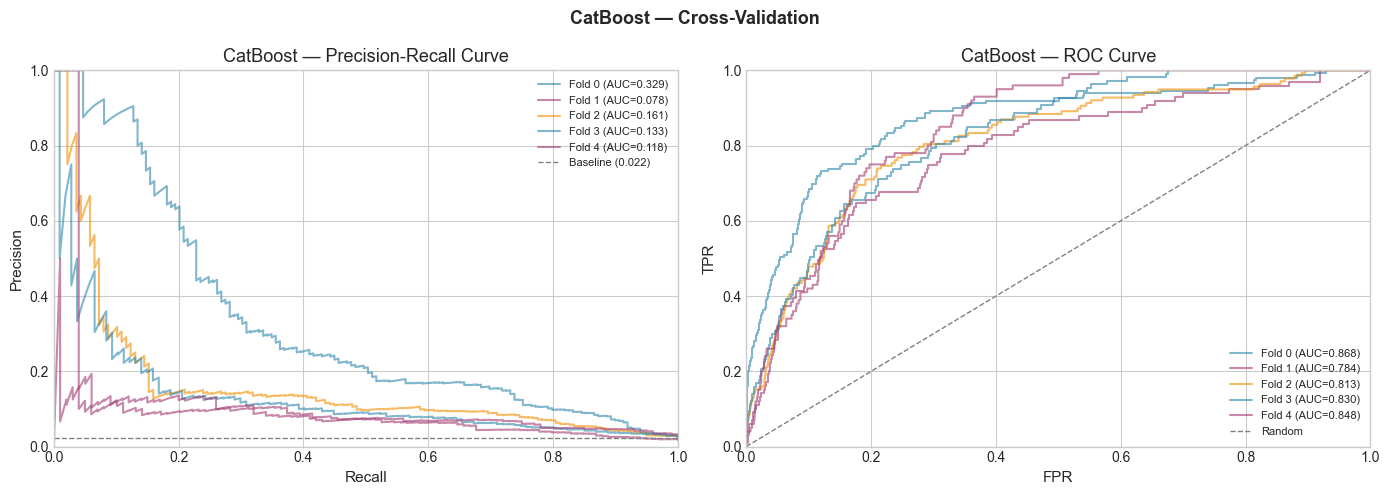

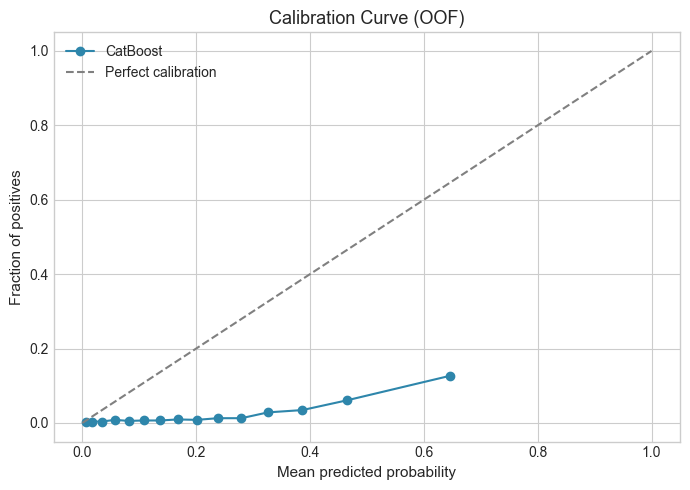

NameError: name 'CB_FEATURE_NAMES' is not defined

In [31]:
oof_cb = np.full(len(y_all), np.nan)
cb_fold_metrics = []
cat_feature_indices = [FINAL_FEATURES.index(c) for c in final_cat if c in FINAL_FEATURES]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for fold_idx, (train_idx, val_idx) in enumerate(splits):
    X_tr_raw = X_all.iloc[train_idx]
    X_va_raw = X_all.iloc[val_idx]
    y_tr = y_all[train_idx]
    y_va = y_all[val_idx]

    X_tr_cb, X_va_cb = prepare_for_trees(X_tr_raw, X_va_raw, final_cat)
    safe_names = sanitize_names(X_tr_cb.columns.tolist())
    X_tr_cb.columns = safe_names
    X_va_cb.columns = safe_names

    train_pool = Pool(X_tr_cb, y_tr, cat_features=cat_feature_indices)
    val_pool   = Pool(X_va_cb, y_va, cat_features=cat_feature_indices)

    cb = CatBoostClassifier(
        iterations=300,
        learning_rate=0.05,
        depth=6,
        loss_function="Logloss",
        eval_metric="AUC",
        random_seed=RANDOM_STATE,
        verbose=0,
        allow_writing_files=False,
        auto_class_weights="Balanced",
    )
    cb.fit(train_pool, eval_set=val_pool, use_best_model=True, early_stopping_rounds=50)

    val_prob = cb.predict_proba(val_pool)[:, 1]
    oof_cb[val_idx] = val_prob

    # ── Metrics ───────────────────────────────────────────────────────────────
    pr_auc  = average_precision_score(y_va, val_prob)
    roc_auc = roc_auc_score(y_va, val_prob)
    best_t, best_f1 = find_optimal_f1(y_va, val_prob)
    y_pred    = (val_prob >= best_t).astype(int)
    precision = precision_score(y_va, y_pred, zero_division=0)
    recall    = recall_score(y_va, y_pred, zero_division=0)
    brier     = brier_score_loss(y_va, val_prob)

    cb_fold_metrics.append({
        "fold": fold_idx, "pr_auc": pr_auc, "roc_auc": roc_auc,
        "f1": best_f1, "precision": precision, "recall": recall,
        "brier": brier, "threshold": best_t,
    })
    print(
        f"  Fold {fold_idx}: PR-AUC={pr_auc:.4f} | ROC-AUC={roc_auc:.4f} | "
        f"F1={best_f1:.4f} | Precision={precision:.4f} | Recall={recall:.4f} | "
        f"Brier={brier:.4f} (thr={best_t:.3f})"
    )

    # ── Curves ────────────────────────────────────────────────────────────────
    prec_c, rec_c, _ = precision_recall_curve(y_va, val_prob)
    fpr, tpr, _      = roc_curve(y_va, val_prob)
    axes[0].plot(rec_c, prec_c, alpha=0.6, label=f"Fold {fold_idx} (AUC={pr_auc:.3f})")
    axes[1].plot(fpr,   tpr,    alpha=0.6, label=f"Fold {fold_idx} (AUC={roc_auc:.3f})")

# ── Summary table ─────────────────────────────────────────────────────────────
cb_metrics_df = pd.DataFrame(cb_fold_metrics)
print(f"\nCatBoost — mean CV:")
for col in ["pr_auc", "roc_auc", "f1", "precision", "recall", "brier"]:
    print(f"  {col:12s}: {cb_metrics_df[col].mean():.4f} ± {cb_metrics_df[col].std():.4f}")

# ── Finish plots ──────────────────────────────────────────────────────────────
baseline = y_all.mean()
axes[0].axhline(baseline, color="gray", ls="--", lw=1, label=f"Baseline ({baseline:.3f})")
axes[0].set_xlabel("Recall");  axes[0].set_ylabel("Precision")
axes[0].set_title("CatBoost — Precision-Recall Curve")
axes[0].legend(fontsize=8);    axes[0].set_xlim(0, 1); axes[0].set_ylim(0, 1)

axes[1].plot([0, 1], [0, 1], color="gray", ls="--", lw=1, label="Random")
axes[1].set_xlabel("FPR");     axes[1].set_ylabel("TPR")
axes[1].set_title("CatBoost — ROC Curve")
axes[1].legend(fontsize=8);    axes[1].set_xlim(0, 1); axes[1].set_ylim(0, 1)

plt.suptitle("CatBoost — Cross-Validation", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# ── Calibration curve ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
frac_pos, mean_pred = calibration_curve(y_all, oof_cb, n_bins=15, strategy="quantile")
ax.plot(mean_pred, frac_pos, marker="o", color=PALETTE["primary"], label="CatBoost")
ax.plot([0, 1], [0, 1], ls="--", color="gray", label="Perfect calibration")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Fraction of positives")
ax.set_title("Calibration Curve (OOF)")
ax.legend()
plt.tight_layout()
plt.show()

# ── Feature importance (top 30) ───────────────────────────────────────────────
fi = pd.Series(cb.get_feature_importance(), index=CB_FEATURE_NAMES).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 7))
fi.head(30).sort_values().plot(kind="barh", ax=ax, color=PALETTE["primary"], edgecolor="white")
ax.set_title("CatBoost — Top 30 Feature Importance")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

CB_FEATURE_NAMES = safe_names